In [1]:
import scib

import warnings
warnings.filterwarnings("ignore")

In [30]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm import trange
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

"""
SCS
PAS
CHAOS
ASW
"""

def _get_spatial_entropy(C, C_sum):
    H = 0
    for i in range(len(C)):
        for j in range(len(C)):
            z = C[i, j]
            if z != 0:
                H += -(z / C_sum) * np.log(z / C_sum)
    return H

# def spatial_entropy(g, labels):
def spatial_entropy(k_neighbors, labels, degree=4):
    """
    Calculates spatial entropy of graph
    """
    # construct contiguity matrix C which counts pairs of cluster edges
    # nx.set_node_attributes(g, labels, "labels")
    # cluster_nums = len(np.unique(list(labels.values())))
    # C = np.zeros((cluster_nums, cluster_nums))
    # for e in g.edges():
    #     C[labels[e[0]]][labels[e[1]]] += 1


    # S = np.repeat(adata.obs[annotation_key].values[:, None], degree, axis=1)
    S = np.broadcast_to(labels[:, None], (len(labels), degree))
    N = labels[k_neighbors]
    cluster_names = np.unique(labels)
    cluster_nums = len(cluster_names)
    C = np.zeros((cluster_nums, cluster_nums))
    for i in range(cluster_nums):
        for j in range(cluster_nums):
            # C[i, j] = np.sum(np.logical_and(N == i, S == j))
            C[i, j] = np.sum(np.logical_and(S == cluster_names[i], N == cluster_names[j]))
    # cluster_names = np.unique(list(labels.values()))
    # C = pd.DataFrame(0,index=cluster_names, columns=cluster_names)
    # C = np.zeros((len(cluster_names), len(cluster_names)))

    # calculate entropy from C
    # C_sum = C.values.sum()
    C_sum = C.sum()
    # print("C_sum", C_sum)
    # H = 0
    # # for i in range(len(cluster_names)):
    # #     for j in range(i, len(cluster_names)):
    # #         if (i == j):
    # #             z = C[cluster_names[i]][cluster_names[j]]
    # #         else:
    # #             z = C[cluster_names[i]][cluster_names[j]] + C[cluster_names[j]][cluster_names[i]]
    # #         if z != 0:
    # #             H += -(z/C_sum)*math.log(z/C_sum)
    # for i in range(len(C)):
    #     for j in range(len(C)):
    #         z = C[i, j]
    #         if z != 0:
    #             H += -(z / C_sum) * np.log(z / C_sum)
    # return H
    return _get_spatial_entropy(C, C_sum)

def spatial_coherence_score(adata, annotation_key, degree=4, rep_time=1000, seed=0):
    spatial_coords = adata.obsm['spatial']
    origin_labels = adata.obs[annotation_key].values
    # Use kneighbors_graph to get the adjacency matrix
    neigh = NearestNeighbors(n_neighbors=degree, metric='euclidean').fit(spatial_coords)
    # adjacency_matrix = neigh.kneighbors_graph(n_neighbors=degree, mode='connectivity').toarray().astype(np.int32)
    k_neighbors = neigh.kneighbors(n_neighbors=degree, return_distance=False)
    true_entropy = spatial_entropy(k_neighbors, origin_labels, degree=degree)
    entropies = []
    rng = np.random.default_rng(seed)
    shuffled_labels = origin_labels.copy()
    # for _ in trange(1000):
    for _ in trange(rep_time):
        rng.shuffle(shuffled_labels)
        entropies.append(spatial_entropy(k_neighbors, shuffled_labels, degree=degree))

    return (true_entropy - np.mean(entropies)) / np.std(entropies), true_entropy, entropies


def CHAOS_score(X, pred_labels):
    """
    Calculate the CHAOS score for a given set of spatial coordinates and predicted labels.

    param: X - spatial coordinates
    param: pred_labels - predicted labels

    return: CHAOS score
    """
    # Standardize the spatial coordinates
    X = StandardScaler().fit_transform(X)

    # Get the unique cluster labels
    cluster_labels = np.unique(pred_labels)

    # Initialize the distance value and count
    dist_val = 0.
    count = 0

    # Iterate through each cluster
    for k in cluster_labels:
        # Get the spatial coordinates for the current cluster
        cluster_coords = X[pred_labels == k, :]

        # Check if there are at least 2 spatial coordinates in the cluster
        if len(cluster_coords) <= 2:
            continue
        else:
            count += len(cluster_coords)

        # Calculate the distance to the nearest neighbor for each spatial coordinate in the cluster
        nbrs = NearestNeighbors(n_neighbors=1).fit(cluster_coords)
        distances, _ = nbrs.kneighbors()

        # Sum the distances
        dist_val = dist_val + np.sum(distances)

    # Calculate the CHAOS score
    return dist_val / count


def PAS_score(X, pred_labels, k=6):
    """
    Calculate the PAS score for a given set of spatial coordinates and predicted labels.

    param: X - spatial coordinates
    param: pred_labels - predicted labels
    param: k - number of nearest neighbors to consider

    return: PAS score
    """
    # Use NearestNeighbors to find the nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    indices = nbrs.kneighbors(return_distance=False)
    # print("type(indices)", type(indices))
    # print("type(pred_labels)", type(pred_labels))
    # print("indices.shape", indices.shape)
    # print("pred_labels.shape", pred_labels.shape)
    # Calculate the PAS score
    return ((pred_labels.reshape(-1, 1) != pred_labels[indices]).sum(1) > k / 2).mean()

In [2]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def pca(adata, use_reps=None, n_comps=10):

    """Dimension reduction with PCA algorithm"""

    from sklearn.decomposition import PCA
    from scipy.sparse.csc import csc_matrix
    from scipy.sparse.csr import csr_matrix
    pca = PCA(n_components=n_comps)
    if use_reps is not None:
       feat_pca = pca.fit_transform(adata.obsm[use_reps])
    else:
       if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
          feat_pca = pca.fit_transform(adata.X.toarray())
       else:
          feat_pca = pca.fit_transform(adata.X)

    return feat_pca

def supervised_clustering(adata, n_clusters=7, key='Garfield', add_key='Garfield_cluster', cluster_method='leiden',
               start=0.5, end=2.0, increment=0.05, use_pca=False, n_comps=20):
    if use_pca:
       adata.obsm[key + '_pca'] = pca(adata, use_reps=key, n_comps=n_comps)

    method_cluster = add_key
    method = key
    
    if cluster_method == 'leiden':
       if use_pca:
          res = search_res(adata, n_clusters, use_rep=key + '_pca', cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       else:
          res = search_res(adata, n_clusters, use_rep=method, cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       sc.tl.leiden(adata, random_state=0, key_added=method_cluster, resolution=res, neighbors_key=method)
    elif cluster_method == 'louvain':
       if use_pca:
          res = search_res(adata, n_clusters, use_rep=key + '_pca', cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       else:
          res = search_res(adata, n_clusters, use_rep=method, cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       sc.tl.louvain(adata, random_state=0, key_added=method_cluster, resolution=res, neighbors_key=method)

def search_res(adata, n_clusters, use_rep='Garfield', cluster_method='leiden', start=0.5, end=2.0,
               increment=0.05, expansion_factor=1.75, max_iter=50):
    '''\
    Searching corresponding resolution according to given cluster number

    Parameters
    ----------
    adata : anndata
        AnnData object of spatial data.
    n_clusters : int
        Target number of clusters.
    method : string
        Tool for clustering. Supported tools include 'leiden' and 'louvain'. The default is 'leiden'.
    use_rep : string
        The indicated representation for clustering.
    start : float
        The start value for searching.
    end : float
        The end value for searching.
    increment : float
        The step size to increase.
    expansion_factor : float
        Factor to expand the search range if no resolution is found in the initial range.
    max_iter : int
        Maximum number of iterations to prevent infinite loops.

    Returns
    -------
    res : float
        Resolution.

    '''
    print('Searching resolution...')
    label = 0
    method = use_rep
    method_cluster = method + '_cluster'
    
    current_start, current_end = start, end
    best_res = None
    best_diff = float('inf')  # Track the best resolution so far
    best_count = 0
    iteration = 0  # Track number of iterations
    
    # 构图
    sc.pp.neighbors(adata, use_rep=use_rep, key_added=method)

    while label == 0 and iteration < max_iter:
        iteration += 1
        for res in sorted(list(np.arange(current_start, current_end, increment)), reverse=True):
            if cluster_method == 'leiden':
                sc.tl.leiden(adata, random_state=0, key_added=method_cluster,
                             resolution=res, neighbors_key=method)
                count_unique = adata.obs[method_cluster].nunique()
            elif cluster_method == 'louvain':
                sc.tl.louvain(adata,  random_state=0, key_added=method_cluster, 
                             resolution=res, neighbors_key=method)
                count_unique = adata.obs[method_cluster].nunique()

            print(f'resolution={res}, cluster number={count_unique}')

            # Update the best resolution if it's closer to the target
            diff = abs(count_unique - n_clusters)
            if diff < best_diff:
                best_diff = diff
                best_res = res
                best_count = count_unique

            if count_unique == n_clusters:
                label = 1
                break

        if label == 0:
            if best_res is not None:
                # Instead of starting from scratch, continue from the closest found resolution
                if best_count > n_clusters:
                    current_start = min(best_res, current_start * 0.9)  # Avoid too small a search range
                    current_end = min(current_start * expansion_factor, end * 2)  # Limit max range
                    print(f"Expanding search range: new range ({current_start}, {current_end})")
                else:
                    current_start = max(best_res, current_start * 1.2)  # Avoid too small a search range
                    current_end = min(current_start * expansion_factor, end * 2)  # Limit max range
                    print(f"Expanding search range: new range ({current_start}, {current_end})")
            else:
                print("Warning: No valid resolution found yet, expanding the search range.")
                current_start *= expansion_factor
                current_end *= expansion_factor

    if iteration >= max_iter:
        print("Warning: Reached maximum iteration limit.")

    return best_res if label == 1 else None

In [33]:
from sklearn import metrics

def count_metrics_for_resolution(dataset, reso_dict=None, n_start_run=1,
                                 n_end_run=8, n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16],
                                 start=0.5, end=2.0, increment=0.05):
    res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'

    result = pd.DataFrame()
    metrics_list = []
    method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']

    # 计算不同方法的指标
    for method in method_list:
        # 读取 adata
        adata = sc.read_h5ad(f'{res_dir}/{dataset}_{method}.h5ad')
        adata.obs['niche_type'] = adata.obs['niche_type'].astype('category')

        # 处理缺失的 niche_type
        if adata.obs["niche_type"].isna().sum() != 0:
            adata.obs["niche_type"] = adata.obs["niche_type"].cat.add_categories(['NaN'])
            adata.obs.loc[adata.obs["niche_type"].isna(), "niche_type"] = 'NaN'
        # adata.obs['batch'] = ['batch1'] * adata.shape[0]

        for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
            latent = adata.obsm[f"{method}_latent_run{run_number}"].copy()
            # latent.index = adata.obs_names
            adata.obsm[method] = latent
            print('the length of niche type:', adata.obs['niche_type'].nunique())
            method_cluster = method+'_cluster'
            method_run_seed = f"{method}_{n_neighbors}_run{run_number}"
            if reso_dict is not None and dataset in reso_dict.keys():
                data_reso_dict = reso_dict[dataset]
                method_reso = data_reso_dict[method_run_seed]
                sc.pp.neighbors(adata, use_rep=method, key_added=method)
                if method_reso is not None:
                    print(f'method_reso is not None, using the {method_reso} as resolution for {method}...')
                    sc.tl.leiden(adata,  random_state=0, key_added=method_cluster,
                                 resolution=method_reso, neighbors_key=method)
                    sc.tl.umap(adata, neighbors_key=method)
                    print('Number of clusters:', adata.obs[method_cluster].nunique())
                else:
                    print('Searching resolution for {}...'.format(method))
                    supervised_clustering(adata, n_clusters=adata.obs['niche_type'].nunique(),
                                          key=method, add_key=method_cluster, cluster_method='leiden',
                                          start=start, end=end, increment=increment)
                    sc.tl.umap(adata, neighbors_key=method)
                    print('Number of clusters:', adata.obs[method_cluster].nunique())
            else:
                print('Searching resolution for {}...'.format(method))
                supervised_clustering(adata, n_clusters=adata.obs['niche_type'].nunique(),
                                      key=method, add_key=method_cluster, cluster_method='leiden',
                                      start=start, end=end, increment=increment)
                sc.tl.umap(adata, neighbors_key=method)
                print('Number of clusters:', adata.obs[method_cluster].nunique())

            # 计算指标
            pred_labels = adata.obs[method_cluster].values
            chaos = CHAOS_score(X=adata.obsm['spatial'], pred_labels=pred_labels)
            pas = PAS_score(X=adata.obsm['spatial'], pred_labels=pred_labels)
            scs = spatial_coherence_score(adata, annotation_key=method_cluster)

            seed = f"{n_neighbors}_run{run_number}"
            metrics_list.append([chaos, pas, scs, method, seed])

    # 保存结果
    df = pd.DataFrame(metrics_list, columns=['CHAOS', 'PAS', 'SCS', 'method', 'n_neighbors'])
    result = pd.concat([result, df], ignore_index=True)
    result['Dataset'] = dataset
    result.to_csv(f'{res_dir}/{dataset}_metrics_result.csv', index=False)
    print(dataset)

    return adata

In [11]:
def count_metrics_for_best_resolution(dataset, n_start_run=1, n_end_run=8,
                                      n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16],):
    res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'

    result = pd.DataFrame()
    metrics_list = []
    method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']

    # 计算不同方法的指标
    for method in method_list:
        # 读取 adata
        adata = sc.read_h5ad(f'{res_dir}/{dataset}_{method}.h5ad')
        adata.obs['niche_type'] = adata.obs['niche_type'].astype('category')

        # 处理缺失的 niche_type
        if adata.obs["niche_type"].isna().sum() != 0:
            adata.obs["niche_type"] = adata.obs["niche_type"].cat.add_categories(['NaN'])
            adata.obs.loc[adata.obs["niche_type"].isna(), "niche_type"] = 'NaN'
        # adata.obs['batch'] = ['batch1'] * adata.shape[0]

        for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
            latent = adata.obsm[f"{method}_latent_run{run_number}"].copy()
            # latent.index = adata.obs_names
            adata.obsm[method] = latent
            print('the length of niche type:', adata.obs['niche_type'].nunique())
            sc.pp.neighbors(adata, use_rep=method)
            sc.tl.umap(adata)
            # 计算指标
            scib.metrics.cluster_optimal_resolution(adata, cluster_key="cluster", label_key="niche_type")

            ari = scib.metrics.ari(adata, cluster_key='cluster', label_key="niche_type")
            nmi = scib.metrics.nmi(adata, cluster_key='cluster', label_key="niche_type")
            # 计算 AMI
            label = adata.obs['niche_type'].values
            pred = adata.obs['cluster'].values
            ami = np.round(metrics.adjusted_mutual_info_score(label, pred), 4)
            # 计算 HOM (Homogeneity)
            hom = np.round(metrics.homogeneity_score(label, pred), 4)
            sht = scib.metrics.silhouette(adata, label_key="niche_type", embed=method, scale=True) #  metric='euclidean',
            seed = f"{n_neighbors}_{run_number}"
            metrics_list.append([ari, nmi, ami, hom, sht, method, seed])

    # 保存结果
    df = pd.DataFrame(metrics_list, columns=['ARI', 'NMI', 'AMI', 'Homogeneity',
                                             'Silhouette', 'method', 'n_neighbors'])
    result = pd.concat([result, df], ignore_index=True)
    result['Dataset'] = dataset
    result.to_csv(f'{res_dir}/{dataset}_metrics_result_stable_reso.csv', index=False)
    print(dataset)
    
    return adata

### 数据集 adata_slideseqv2

#### 探索一下用最佳分辨率

In [12]:
# calculate the metrics based on the best resolution
adata = count_metrics_for_best_resolution('adata_slideseqv2')
adata

the length of niche type: 10
resolution: 0.1, nmi: 0.611769398452685
resolution: 0.2, nmi: 0.6877243747758401
resolution: 0.3, nmi: 0.6990416857139183
resolution: 0.4, nmi: 0.7226414625666756
resolution: 0.5, nmi: 0.7330794841036452
resolution: 0.6, nmi: 0.7073157798765507
resolution: 0.7, nmi: 0.6956193812231659
resolution: 0.8, nmi: 0.6549185986181364
resolution: 0.9, nmi: 0.6436393962024051
resolution: 1.0, nmi: 0.6280555159693005
resolution: 1.1, nmi: 0.6342406414945128
resolution: 1.2, nmi: 0.6163447674841933
resolution: 1.3, nmi: 0.6214211101924596
resolution: 1.4, nmi: 0.6095131764092586
resolution: 1.5, nmi: 0.6113453512995595
resolution: 1.6, nmi: 0.5985723988892423
resolution: 1.7, nmi: 0.5893123211274774
resolution: 1.8, nmi: 0.5826338027562944
resolution: 1.9, nmi: 0.5852797779525123
resolution: 2.0, nmi: 0.5816212367301613
optimised clustering against niche_type
optimal cluster resolution: 0.5
optimal score: 0.7330794841036452
the length of niche type: 10
resolution: 0.1, 

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'niche_type', 'cluster'
    uns: 'graphst_model_training_duration_run1', 'graphst_model_training_duration_run2', 'graphst_model_training_duration_run3', 'graphst_model_training_duration_run4', 'graphst_model_training_duration_run5', 'graphst_model_training_duration_run6', 'graphst_model_training_duration_run7', 'graphst_model_training_duration_run8', 'neighbors', 'umap', 'cluster'
    obsm: 'graphst_latent_run1', 'graphst_latent_run2', 'graphst_latent_run3', 'graphst_latent_run4', 'graphst_latent_run5', 'graphst_latent_run6', 'graphst_latent_run7', 'graphst_latent_run8', 'spatial', 'graphst', 'X_umap'
    obsp: 'distances', 'connectivities'

In [27]:
method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
dataset = 'adata_slideseqv2'

df = pd.read_csv(f'{save_path}/{dataset}_metrics_result_stable_reso.csv')
# df = df.drop('Dataset', axis=0)
## 将df['n_neighbors']数据转为特定格式，如 12_5 -> 12_run5
df['n_neighbors'] = df['n_neighbors'].apply(lambda x: x.split('_')[0] + '_run' + x.split('_')[1])
# 将method列首字母大写
df['method'] = df['method'].apply(lambda x: x.capitalize())
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,ARI,NMI,AMI,Homogeneity,Silhouette,method,n_neighbors,Dataset
0,0.730404,0.733079,0.7329,0.7510,0.609583,Garfield,4_run1,adata_slideseqv2
1,0.749393,0.733988,0.7338,0.7510,0.610073,Garfield,4_run2,adata_slideseqv2
2,0.722380,0.723864,0.7237,0.7332,0.608027,Garfield,8_run3,adata_slideseqv2
3,0.710969,0.705972,0.7058,0.7356,0.605392,Garfield,8_run4,adata_slideseqv2
4,0.703861,0.701820,0.7017,0.7107,0.605680,Garfield,12_run5,adata_slideseqv2
5,0.685109,0.691370,0.6912,0.6837,0.606688,Garfield,12_run6,adata_slideseqv2
6,0.624347,0.664271,0.6641,0.6267,0.604157,Garfield,16_run7,adata_slideseqv2
7,0.691728,0.695149,0.6950,0.7151,0.603763,Garfield,16_run8,adata_slideseqv2
8,0.509852,0.579501,0.5793,0.5968,0.593964,Nichecompass,4_run1,adata_slideseqv2
9,0.437365,0.560029,0.5598,0.6004,0.593760,Nichecompass,4_run2,adata_slideseqv2


In [29]:
# 根据 n_neighbors 对数据进行提取
n_neighbors = '4_run2'
tmp = df[df['n_neighbors'] == n_neighbors]
tmp

,ARI,NMI,AMI,Homogeneity,Silhouette,method,n_neighbors,Dataset
1,0.749393,0.733988,0.7338,0.7510,0.610073,Garfield,4_run2,adata_slideseqv2
9,0.437365,0.560029,0.5598,0.6004,0.593760,Nichecompass,4_run2,adata_slideseqv2
17,0.563494,0.598403,0.5982,0.6032,0.553270,Cellcharter,4_run2,adata_slideseqv2
25,0.406950,0.507712,0.5074,0.5388,0.507589,Graphst,4_run2,adata_slideseqv2


In [ ]:
## 记录resolution
reso_dict = {
    'adata_slideseqv2': {
        'garfield_4_run1': 0.5,
        'garfield_4_run2': 0.5,
        'garfield_8_run3': 0.5,
        'garfield_8_run4': 0.5,
        'garfield_12_run5': 0.5,
        'garfield_12_run6': 0.4,
        'garfield_16_run7': 0.2,
        'garfield_16_run8': 0.5,

        'nichecompass_4_run1': 0.2,
        'nichecompass_4_run2': 0.2,
        'nichecompass_8_run3': 0.2,
        'nichecompass_8_run4': 0.2,
        'nichecompass_12_run5': 0.3,
        'nichecompass_12_run6': 0.2,
        'nichecompass_16_run7': 0.2,
        'nichecompass_16_run8': 0.1,

        'cellcharter_4_run1': 0.4,
        'cellcharter_4_run2': 0.4,
        'cellcharter_8_run3': 0.4,
        'cellcharter_8_run4': 0.4,
        'cellcharter_12_run5': 0.5,
        'cellcharter_12_run6': 0.4,
        'cellcharter_16_run7': 0.4,
        'cellcharter_16_run8': 0.4,

        'graphst_4_run1': 0.3,
        'graphst_4_run2': 0.5,
        'graphst_8_run3': 0.5,
        'graphst_8_run4': 0.6,
        'graphst_12_run5': 0.4,
        'graphst_12_run6': 0.3,
        'graphst_16_run7': 0.3,
        'graphst_16_run8': 0.4
    }
}

# search the resolution for each method
adata = count_metrics_for_resolution('adata_slideseqv2', reso_dict=reso_dict)
adata

In [35]:
method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
dataset = 'adata_slideseqv2'

df = pd.read_csv(f'{save_path}/{dataset}_metrics_result.csv')
# df = df.drop('Dataset', axis=0)
## 将df['n_neighbors']数据转为特定格式，如 12_5 -> 12_run5
# df['n_neighbors'] = df['n_neighbors'].apply(lambda x: x.split('_')[0] + '_run' + x.split('_')[1])
# 将method列首字母大写
df['method'] = df['method'].apply(lambda x: x.capitalize())
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,CHAOS,PAS,SCS,method,n_neighbors,Dataset
0,0.017296,0.191595,"(-1219.3753569697667, 3.09428503662618, [4.241...",Garfield,4_run1,adata_slideseqv2
1,0.017333,0.192576,"(-1149.1947326255383, 3.126152555020689, [4.23...",Garfield,4_run2,adata_slideseqv2
2,0.016842,0.163045,"(-1193.4361445855636, 2.987866555464355, [4.14...",Garfield,8_run3,adata_slideseqv2
3,0.017650,0.192959,"(-1148.1458228730912, 3.218956820818417, [4.38...",Garfield,8_run4,adata_slideseqv2
4,0.016810,0.155961,"(-1223.457073345468, 2.977050559084417, [4.148...",Garfield,12_run5,adata_slideseqv2
5,0.016465,0.129278,"(-1389.4200418578985, 2.7500218533481227, [3.9...",Garfield,12_run6,adata_slideseqv2
6,0.015546,0.103336,"(-1272.892548217869, 2.441560234369314, [3.587...",Garfield,16_run7,adata_slideseqv2
7,0.017037,0.154406,"(-1226.9067740371918, 3.0244045852666424, [4.2...",Garfield,16_run8,adata_slideseqv2
8,0.013361,0.016920,"(-2108.945120009683, 2.3622605545048665, [4.28...",Nichecompass,4_run1,adata_slideseqv2
9,0.013443,0.020318,"(-2794.3230071228945, 2.563174666421941, [4.62...",Nichecompass,4_run2,adata_slideseqv2


In [17]:
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'niche_type'
    uns: 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8'
    obsm: 'garfield_latent_run1', 'garfield_latent_run2', 'garfield_latent_run3', 'garfield_latent_run4', 'garfield_latent_run5', 'garfield_latent_run6', 'garfield_latent_run7', 'garfield_latent_run8', 'spatial'

In [22]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

/tmp/ipykernel_3475582/2197935796.py:5: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed in 3.10.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("Agg") #使用非交互式的后端生成图像文件


In [25]:
import matplotlib.pyplot as plt
sc.settings.set_figure_params(dpi=100, facecolor='white')

dataset = 'adata_slideseqv2'
res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
run_number = '2'

reso_dict = {
    'adata_slideseqv2': {
        'garfield_4_run2': 0.5,
        'nichecompass_4_run2': 0.2,
        'cellcharter_4_run2': 0.4,
        'graphst_4_run2': 0.5
    }
}

method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']
for method in method_list:
    adata = sc.read_h5ad(f'{res_dir}/{dataset}_{method}.h5ad')
    # adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正
    latent_key = f"{method}_latent_run{run_number}"

    if reso_dict is not None:
        data_reso_dict = reso_dict[dataset]
        method_reso = data_reso_dict[f'{method}_4_run2']
        sc.pp.neighbors(adata, use_rep=latent_key, key_added=latent_key)
        print(f'method_reso is not None, using the {method_reso} as resolution for {method}...')
        sc.tl.leiden(adata,  random_state=0, key_added=method,
                     resolution=method_reso, neighbors_key=latent_key)
        print('Number of clusters:', adata.obs[method].nunique())

    sc.tl.umap(adata, neighbors_key=latent_key)
    # Create a new figure for each plot with an appropriate size
    plt.figure(figsize=(6, 6))  # Adjust the figsize as needed
    # sc.pl.umap(adata, color=[method],
    #            wspace=0.5, hspace=0.5, show=False, ncols=2)
    # # Save the figure
    # pic(os.path.join(res_dir, f"UMAP_plot_niche_{method}.pdf"))
    # plt.savefig(res_dir + f"/{latent_key}_UMAP_clusters.pdf", bbox_inches='tight')  # Use bbox_inches to ensure full legend display
    # plt.close()

    sc.pl.embedding(adata, basis='spatial', color=method,
                    title=f'{method} niches', s=5, show=False)
    # plt.gca().invert_yaxis()  # 翻转 y 轴
    # plt.show()
    pic(os.path.join(res_dir, f"spatial_plot_niche_{method}.pdf"))

method_reso is not None, using the 0.5 as resolution for garfield...
Number of clusters: 11
method_reso is not None, using the 0.2 as resolution for nichecompass...
Number of clusters: 12
method_reso is not None, using the 0.4 as resolution for cellcharter...
Number of clusters: 11
method_reso is not None, using the 0.5 as resolution for graphst...
Number of clusters: 14


### metrics plot

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.formatters import tickcross
from plottable.plots import bar

In [2]:
## define functions
def plot_simple_metrics_table(df,
                              model_col,
                              model_col_width,
                              group_col,
                              metric_cols,
                              metric_col_weights,
                              metric_col_titles=None,
                              metric_col_width=1.5,
                              aggregate_col_width=1.5,
                              plot_width=15,
                              plot_height=10,
                              group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis"},
                              overall_score_col="Overall Score",
                       show=True,
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]

    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    df.columns = [col if overall_score_col not in col else overall_score_col for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if ((group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            print(sorted_group_metrics_col_list)
            df[f"Overall Score ({i})"] = np.average(df[sorted_group_metrics_col_list],
                                                    weights=metric_col_weights,
                                                    axis=1)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]

        overall_sore_metrics_df = df[sorted_metrics_col_list]

        print(sorted_metrics_col_list)
        df["Overall Score (All)"] = np.average(overall_sore_metrics_df,
                                               weights=metric_col_weights * len(groups),
                                               axis=1)
        df.sort_values(by=["Overall Score (All)"], inplace=True, ascending=False)

    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)], key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list + [overall_score_col]]
        df.sort_values(by=[overall_score_col], inplace=True, ascending=False)

    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]

    aggregate_cols = [col for col in list(df.columns) if overall_score_col in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = "\nRaw Metrics"
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Scaled\nAggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]

    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab


def plot_metrics_table(df,
                       model_col,
                       model_col_width,
                       group_col,
                       metric_cols,
                       metric_col_weights,
                       metric_col_titles=None,
                       metric_col_width=1.5,
                       aggregate_col_width=1.5,
                       plot_width=15,
                       plot_height=10,
                       group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis (100%)"},
                       show=True,
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]

    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if (("Overall" not in col) & (group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            df.rename(columns={f"{group}_Overall Score": f"Overall Score ({i})"}, inplace=True)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]
        df.sort_values(by=[f"Overall Score (0)"], inplace=True, ascending=False)

        # Create separate dataframe to fill nan values with values of worst method
        overall_sore_metrics_df = df[sorted_metrics_col_list].copy()
        for column in overall_sore_metrics_df.columns:
            min_value = overall_sore_metrics_df[column].min()
            overall_sore_metrics_df.fillna({column: min_value}, inplace=True)
    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)],
                                  key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list]
        df["Overall Score"] = np.average(df[sorted_metrics_col_list],
                                         weights=metric_col_weights,
                                         axis=1)
        df.sort_values(by=["Overall Score"], inplace=True, ascending=False)
        # df.drop("Overall Score (All)", axis=1, inplace=True)

    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]

    aggregate_cols = [col for col in list(df.columns) if "Overall" in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = ""
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Aggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]

    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab

In [3]:
method_list = ['garfield', 'nichecompass', 'cellcharter', 'graphst']
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
dataset = 'adata_slideseqv2'

df = pd.read_csv(f'{save_path}/{dataset}_metrics_result_stable_reso.csv')
# df = df.drop('Dataset', axis=0)
## 将df['n_neighbors']数据转为特定格式，如 12_5 -> 12_run5
df['n_neighbors'] = df['n_neighbors'].apply(lambda x: x.split('_')[0] + '_run' + x.split('_')[1])
# 将method列首字母大写
df['method'] = df['method'].apply(lambda x: x.capitalize())
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

FileNotFoundError: [Errno 2] No such file or directory: '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/adata_slideseqv2_metrics_result_stable_reso.csv'

In [ ]:
# 修改列名
df.columns = ['ARI', 'NMI', 'AMI', 'HOM', 'ASW', 'Method', 'n_neighbors', 'Dataset']

In [5]:
metric_cols_single_sample = [
    "ARI", "NMI",  # celltype coherence
    "AMI", "HOM", "ASW" # # local molecular consistency
]
metric_col_weights_single_sample = [ # separate for each category (later multiplied with category_col_weights)
    (1/5), (1/5), # global spatial consistency
    (1/5), (1/5), (1/5) # local spatial consistency
    #(1/4), (1/4), # niche clustering performance
]
metric_col_titles_single_sample = [
    "ARI", # adjusted Rand index
    "NMI", # normalized mutual information
    "AMI", # cell-type separation local inverse Simpson's index
    "HOM", # average silhouette width of cell types
    "ASW"
]

category_cols_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]
category_col_weights_single_sample = [
    1.0,
    1.0]
category_col_titles_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]

### 单独一个个图画

### replicate-1

In [6]:
datasets = ['4_run1', '8_run3',
            '12_run5','16_run7']
models = ['Garfield', 'Nichecompass', 'Cellcharter', 'Graphst']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
    dataset_df = pd.read_csv(f'{res_dir}/adata_slideseqv2_metrics_result_best_reso.csv')
    dataset_df['n_neighbors'] = dataset_df['n_neighbors'].apply(lambda x: x.split('_')[0] + '_run' + x.split('_')[1])
    # 根据n_neighbors列提取数据
    dataset_df = dataset_df[dataset_df['n_neighbors'] == dataset]

    # 将method列首字母大写
    dataset_df['method'] = dataset_df['method'].apply(lambda x: x.capitalize())
    # 修改列名
    dataset_df.columns = ['ARI', 'NMI', 'AMI', 'HOM', 'ASW', 'model', 'dataset', 'Dataset']

    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue

# raw
cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample]
# cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[3:4]]
# scaled
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:3]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[3:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],weights=metric_col_weights_single_sample,
                                                        axis=1)
# summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[3:4],
#                                                         axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:1]],
                                         weights=category_col_weights_single_sample[:1],
                                         axis=1)

# Reformat for plot
# summary_df.replace({"nichecompass_gatv2conv": "NicheCompass",
#                     "nichecompass_gcnconv": "NicheCompass Light",
#                     "staci": "STACI",
#                     "deeplinc": "DeepLinc",
#                     "expimap": "expiMap",
#                     "graphst": "GraphST",
#                     "cellcharter": "CellCharter",
#                     "banksy": "BANKSY"}, inplace=True)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df,
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type",
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "Nichecompass", "DeepLinc", "Graphst", "Cellcharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

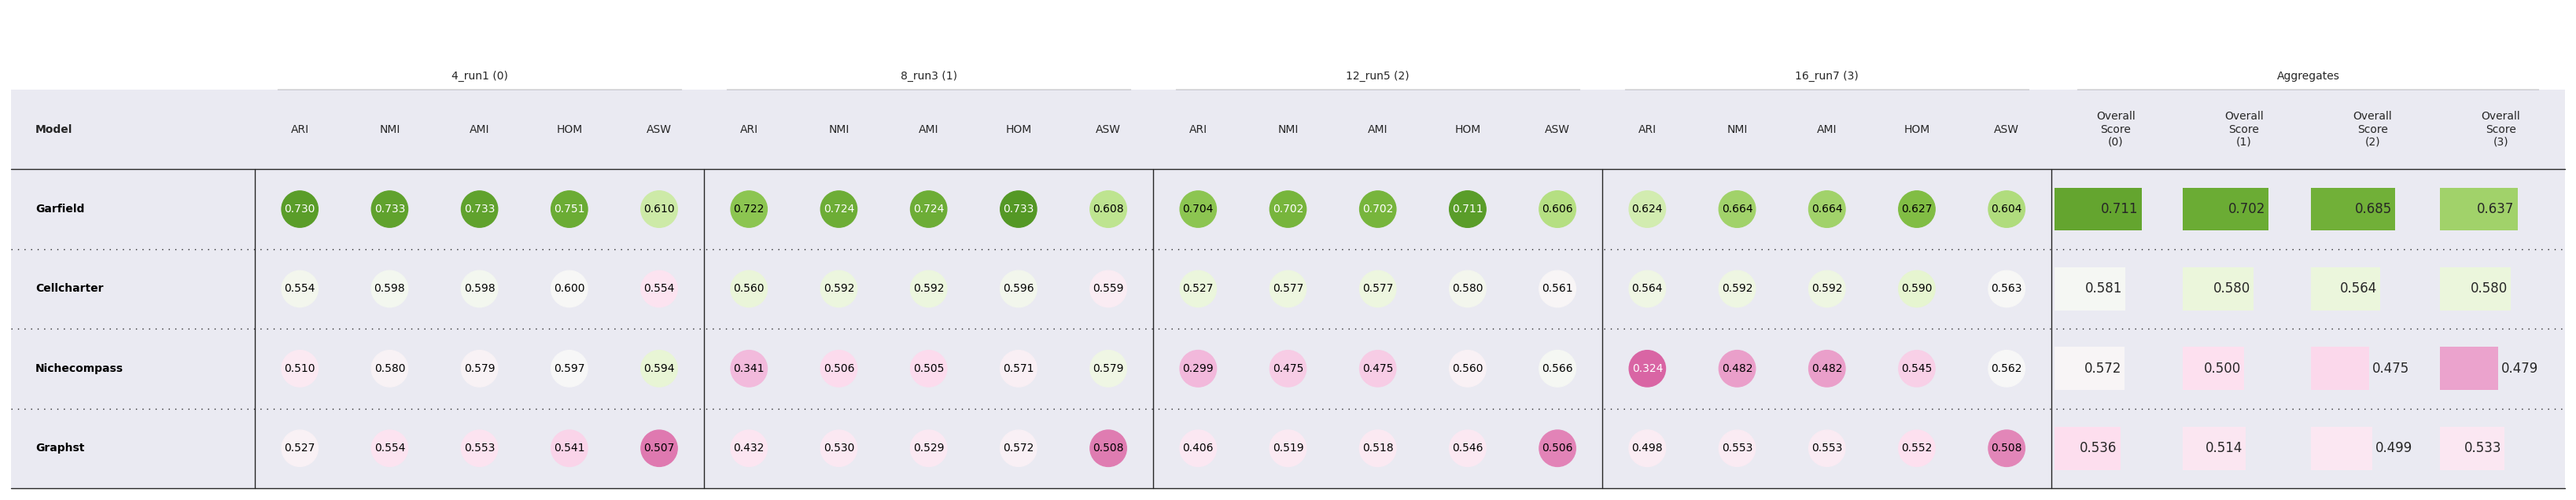

In [7]:
# Plot table
res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
benchmarking_folder_path = f"{res_dir}/"


plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name="benchmarking_metrics_spatial_unimodal_rep1.pdf")

### replicate-2

In [8]:
datasets = ['4_run2', '8_run4',
            '12_run6','16_run8']
models = ['Garfield', 'Nichecompass', 'Cellcharter', 'Graphst']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
    dataset_df = pd.read_csv(f'{res_dir}/adata_slideseqv2_metrics_result_best_reso.csv')
    dataset_df['n_neighbors'] = dataset_df['n_neighbors'].apply(lambda x: x.split('_')[0] + '_run' + x.split('_')[1])
    # 根据n_neighbors列提取数据
    dataset_df = dataset_df[dataset_df['n_neighbors'] == dataset]

    # 将method列首字母大写
    dataset_df['method'] = dataset_df['method'].apply(lambda x: x.capitalize())
    # 修改列名
    dataset_df.columns = ['ARI', 'NMI', 'AMI', 'HOM', 'ASW', 'model', 'dataset', 'Dataset']

    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue

# raw
cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample]
# cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[3:4]]
# scaled
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:3]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[3:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],weights=metric_col_weights_single_sample,
                                                        axis=1)
# summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[3:4],
#                                                         axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:1]],
                                         weights=category_col_weights_single_sample[:1],
                                         axis=1)

# Reformat for plot
# summary_df.replace({"nichecompass_gatv2conv": "NicheCompass",
#                     "nichecompass_gcnconv": "NicheCompass Light",
#                     "staci": "STACI",
#                     "deeplinc": "DeepLinc",
#                     "expimap": "expiMap",
#                     "graphst": "GraphST",
#                     "cellcharter": "CellCharter",
#                     "banksy": "BANKSY"}, inplace=True)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df,
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type",
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "Nichecompass", "DeepLinc", "Graphst", "Cellcharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

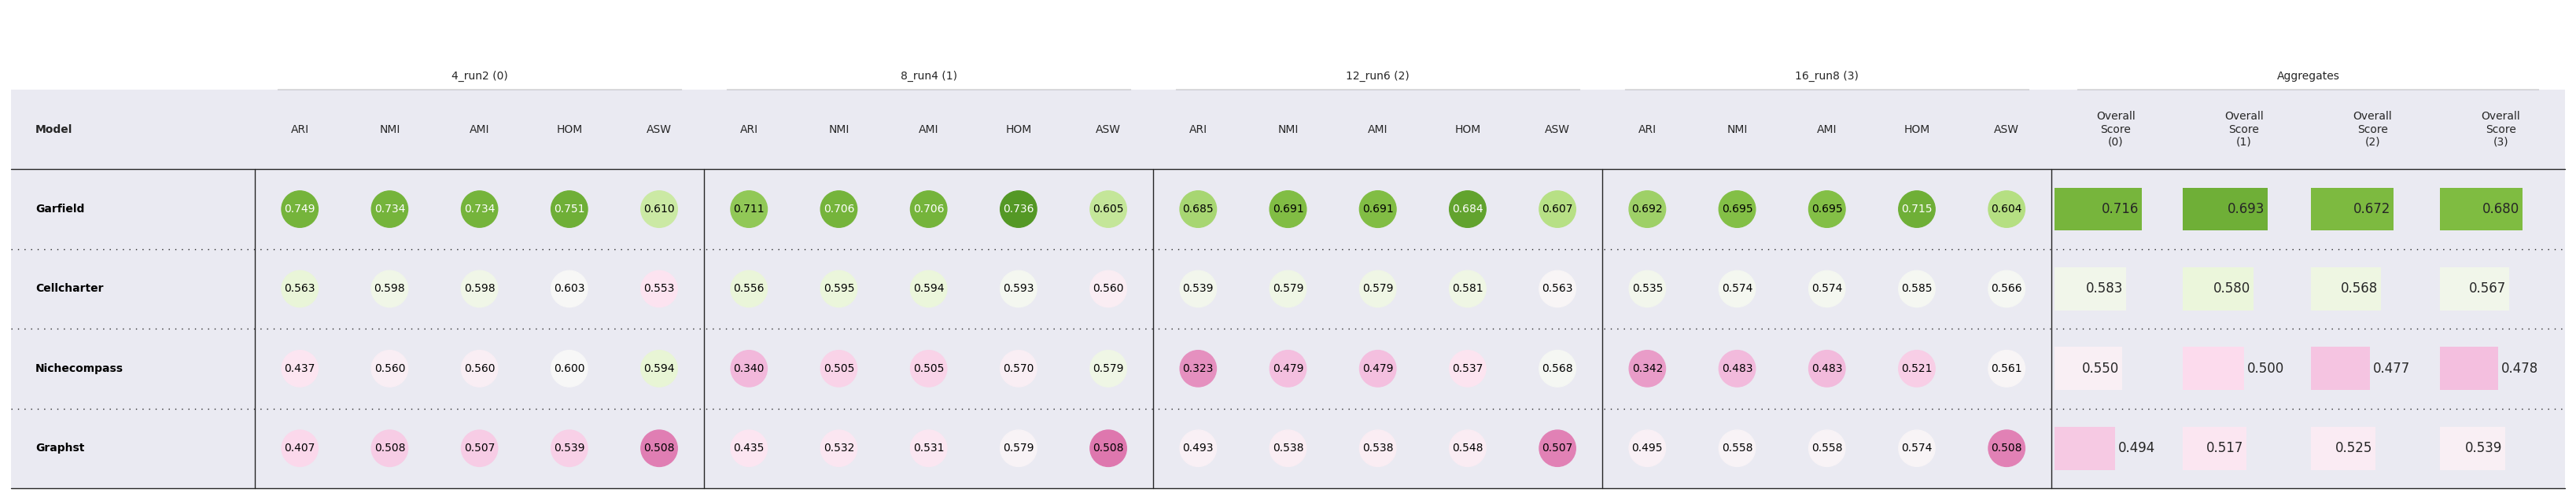

In [9]:
# Plot table
res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
benchmarking_folder_path = f"{res_dir}/"


plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name="benchmarking_metrics_spatial_unimodal_rep2.pdf")

### 多个图合并一起画

In [9]:
## 前5个数据集
datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq","3_brain_SNARE",
            "4_brain_ISSAAC_seq", "5_human_brain_10x"]
models = ['Garfield', 'Multigrate', 'MultiVI', 'MOFA', 'Seurat']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
    dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result.csv') # _best_reso
    dataset_df.drop(columns=["Isolated_Labels_ASW"], inplace=True)
    dataset_df.columns = ["ARI", "NMI", "cLISI", "cASW", "model", "dataset"]

    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue

# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:2]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[2:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[0:2]]
cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[2:4]]

summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[0:2],
                                                        axis=1)
summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[2:4],
                                                        axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:2]],
                                         weights=category_col_weights_single_sample[:2],
                                         axis=1)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df,
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type",
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "STACI", "DeepLinc", "GraphST", "CellCharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

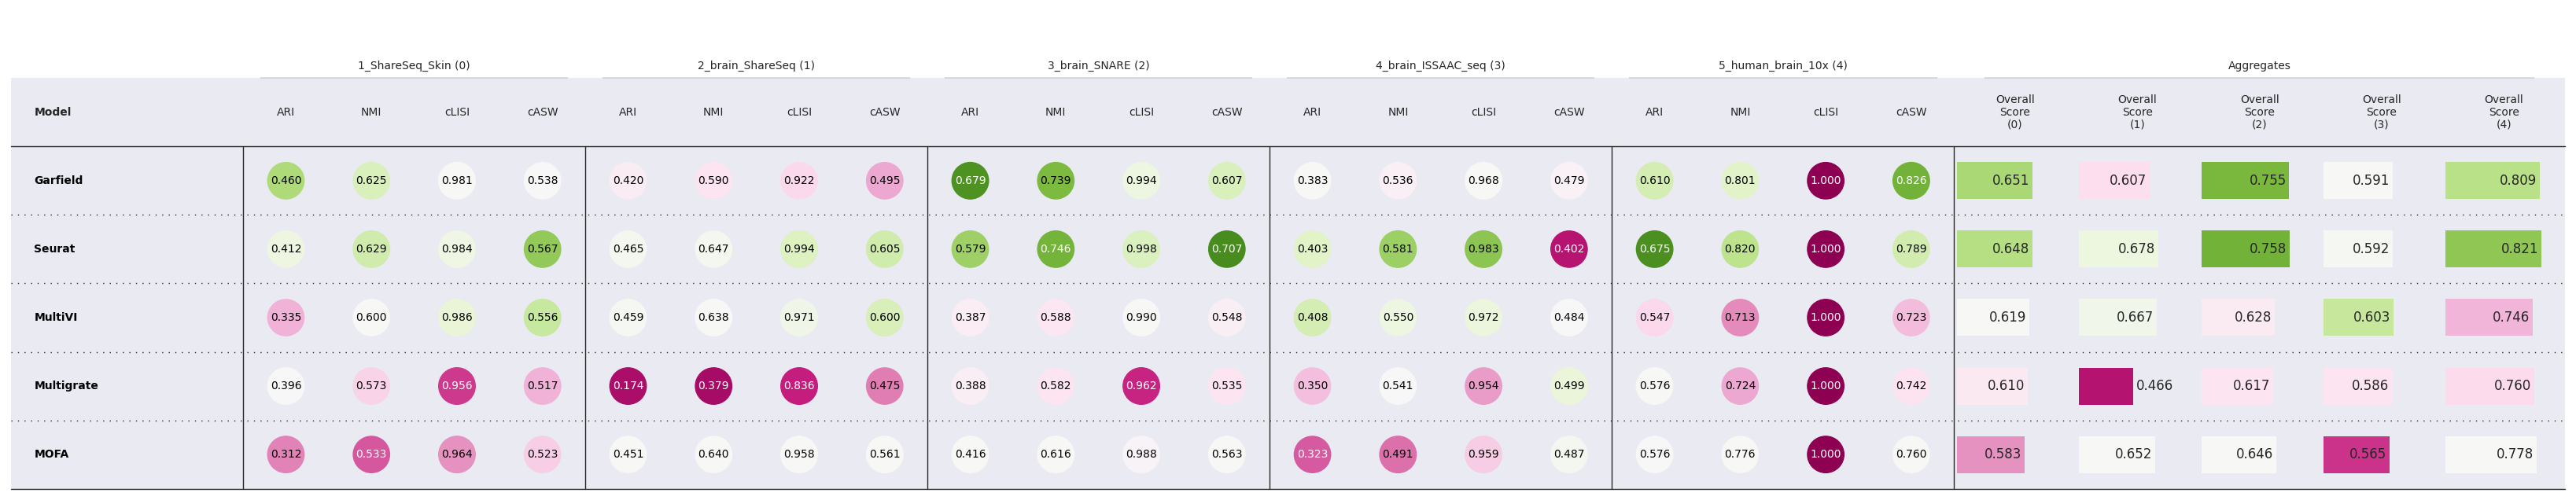

In [10]:
### Supplementary fig. 15b: single sample metric averages ###
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
benchmarking_folder_path = f"{res_dir}/"

plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name=f"benchmarking_metrics_paired_scRNA_ATAC_D1-5.svg")